In [1]:
import numpy as np
import torch
import nibabel as nib
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(device_str)

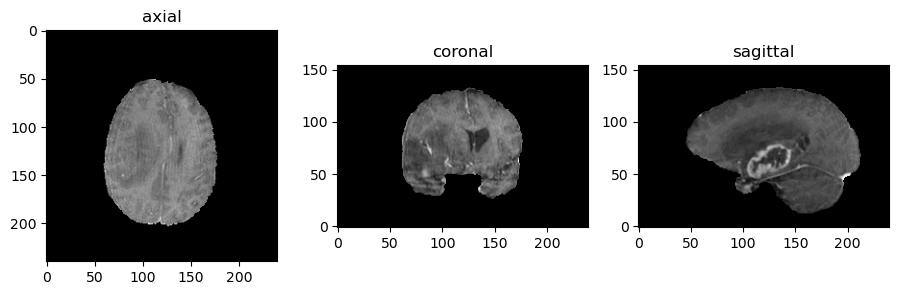

In [2]:
"""
Each 3D MRI has 4 different volumes:
1. Native (t1) - these are largely useless as they don't show very distinct tumor regions
2. Post-constrast t1-weighted (t1ce)
3. t2-weighted (t2)
4. t2 fluid attenuated inversion recovery (flair)

Our labels (the mask's pixel values we want to be able to predict):
0: Unlabeled (background)
1: Necrotic and non-enhancing tumor core (NCR/NET)
2: Peritumoral edema (ED)
3: Missing
4: GD-enhancing tumor (ET)
"""

data_dir = '/home/omkos333/projects/brainseg/data/raw' # base data directory
proj_dir = '/home/omkos333/projects/brainseg' # base project directory

data_num = 1
scan_type = "t1ce"

example = nib.load(data_dir + f'/BraTS20_Training_{data_num:03d}' + f'/BraTS20_Training_{data_num:03d}_{scan_type}.nii') # join base paths with specific nifti filename to get a complete file path

original = example.get_fdata() # convert nifti file into a numpy memmap for easy read
                               # original is an axial cross-section to begin with (rotated left once)

plt.rcParams['figure.figsize'] = [4, 4]

axial = np.einsum('xyz->yxz', original) # axial cross-section
coronal = np.einsum('xyz->zxy', original) # coronal cross-section
sagittal = np.einsum('xyz->zyx', original) # sagittal cross-section

fig, axs = plt.subplots(1, 3, figsize=(11, 3))

axs[0].imshow(axial[:, :, 100], cmap='gray')
axs[0].set_title('axial')

axs[1].imshow(coronal[:, :, 100], cmap='gray', origin='lower')
axs[1].set_title('coronal')

axs[2].imshow(sagittal[:, :, 100], cmap='gray', origin='lower')
axs[2].set_title('sagittal')

plt.show()

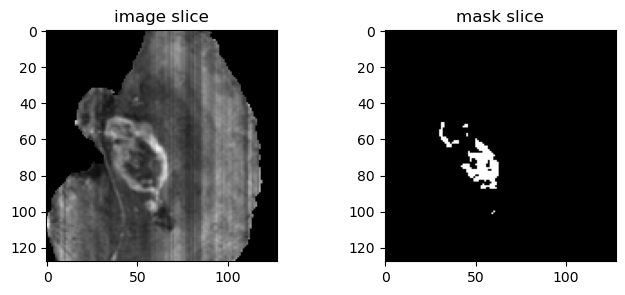

In [3]:
# example of what we need to do to make our data useable
scaler = MinMaxScaler() # used to scale all voxels to [0, 1]

test_img_flair = nib.load(data_dir + '/BraTS20_Training_001' + '/BraTS20_Training_001_flair.nii').get_fdata()
test_img_flair = scaler.fit_transform(test_img_flair.reshape(-1, test_img_flair.shape[-1])).reshape(test_img_flair.shape) # scaler.fit_transform needs a 2D matrix

test_img_t1ce = nib.load(data_dir + '/BraTS20_Training_001' + '/BraTS20_Training_001_t1ce.nii').get_fdata()
test_img_t1ce = scaler.fit_transform(test_img_t1ce.reshape(-1, test_img_t1ce.shape[-1])).reshape(test_img_t1ce.shape)

test_img_t2 = nib.load(data_dir + '/BraTS20_Training_001' + '/BraTS20_Training_001_t2.nii').get_fdata()
test_img_t2 = scaler.fit_transform(test_img_t2.reshape(-1, test_img_t2.shape[-1])).reshape(test_img_t2.shape)

test_mask = nib.load(data_dir + '/BraTS20_Training_001' + '/BraTS20_Training_001_seg.nii').get_fdata()
test_mask = test_mask.astype(np.uint8) # convert original float values into integers to save memory

# reassign label 4 to the index of label 3 because of the 5 labels [0, 1, 2, 3, 4], 3 is unused in the masks for some reason
test_mask[test_mask == 4] = 3

# creating a multi-channel 3D numpy memmap (on disk, not on RAM) that stacks flair, t1ce, and t2 scan types
combined_imgs = np.stack([test_img_flair, test_img_t1ce, test_img_t2], axis=3)

combined_imgs = combined_imgs[56:184, 56:184, 13:141] # crop from non-cubic and largely blank (240, 240, 155) to cubic (128, 128, 128)
test_mask = test_mask[56:184, 56:184, 13:141] # crop the corresponding mask that was approved by neuroradiologists

# convert a (d, h, w) integer mask to one-hot (d, h, w, num_classes)
def to_one_hot(mask, num_classes):
    shape = mask.shape
    one_hot = np.zeros(shape + (num_classes,), dtype=np.uint8)
    for c in range(num_classes):
        one_hot[..., c] = (mask == c).astype(np.uint8)
    return one_hot

test_mask = to_one_hot(test_mask, num_classes=4)

fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].imshow(combined_imgs[40, :, :, 1], cmap='gray')
axs[0].set_title('image slice')

axs[1].imshow(test_mask[40, :, :, 1], cmap='gray')
axs[1].set_title('mask slice')

plt.show()